In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
folder = './Data/'

In [3]:
# Load all three CSV files
df_width = pd.read_csv(folder + 'widthConstant.csv', header=None)
df_length = pd.read_csv(folder + 'lengthConstant.csv', header=None)
df_intensity = pd.read_csv(folder + 'intensityConstant.csv', header=None)

In [4]:
# Extract metadata (should be the same across all files)
metadata = df_width.iloc[:, :3].copy()
metadata.columns = ['y_coordinate', 'z_coordinate', 'power']

In [9]:
# Extract metadata from each file
metadata_width = df_width.iloc[:, :3].copy()
metadata_width.columns = ['y_coordinate', 'z_coordinate', 'power']

metadata_length = df_length.iloc[:, :3].copy()
metadata_length.columns = ['y_coordinate', 'z_coordinate', 'power']

metadata_intensity = df_intensity.iloc[:, :3].copy()
metadata_intensity.columns = ['y_coordinate', 'z_coordinate', 'power']

In [10]:
# Verify metadata consistency 
if not (metadata_width.equals(metadata_length) and metadata_width.equals(metadata_intensity)):
    print("WARNING: Metadata differs between files!")

In [11]:
# Extract measurement data
width_data = df_width.iloc[:, 3:]
length_data = df_length.iloc[:, 3:]
intensity_data = df_intensity.iloc[:, 3:]

In [12]:
print(f"Data loaded. Number of scan lines: {len(metadata)}")
print(f"Preview of metadata (y, z, power):")
print(metadata.head())

Data loaded. Number of scan lines: 488
Preview of metadata (y, z, power):
   y_coordinate  z_coordinate  power
0          0.05          0.05    180
1          0.10          0.05    180
2          0.15          0.05    180
3          0.20          0.05    180
4          0.25          0.05    180


In [13]:
# Create stats dataframe with metadata
stats = pd.DataFrame()
stats['y'] = metadata['y_coordinate']
stats['z'] = metadata['z_coordinate']
stats['power'] = metadata['power']

In [14]:
# Calculate statistics for each measurement type
for data, prefix in [(width_data, 'width'), (length_data, 'length'), (intensity_data, 'intensity')]:
    # Replace zeros with NaN for calculations
    clean_data = data.replace(0, np.nan)
    stats[f'{prefix}_mean'] = clean_data.mean(axis=1)
    stats[f'{prefix}_median'] = clean_data.median(axis=1)
    stats[f'{prefix}_std'] = clean_data.std(axis=1)
    stats[f'{prefix}_p5'] = clean_data.quantile(0.05, axis=1)
    stats[f'{prefix}_p95'] = clean_data.quantile(0.95, axis=1)
    stats[f'{prefix}_range'] = clean_data.max(axis=1) - clean_data.min(axis=1)

print("\nStatistical indicators (first 5 rows):")
print(stats.head())


Statistical indicators (first 5 rows):
      y     z  power  width_mean  width_median  width_std  width_p5  \
0  0.05  0.05    180   19.642202          20.0   2.608827      16.0   
1  0.10  0.05    180   18.899083          19.0   2.666476      16.0   
2  0.15  0.05    180   20.073394          20.0   3.301813      16.0   
3  0.20  0.05    180   20.275229          20.0   3.105764      17.0   
4  0.25  0.05    180   19.564815          19.0   2.865434      16.0   

   width_p95  width_range  length_mean  ...  length_std  length_p5  \
0      25.00         18.0    23.871560  ...    4.694561      16.00   
1      23.00         21.0    20.284404  ...    2.981709      16.40   
2      26.60         25.0    22.110092  ...    4.869290      15.00   
3      27.60         19.0    19.247706  ...    2.997394      14.40   
4      24.65         17.0    20.083333  ...    4.547003      14.35   

   length_p95  length_range  intensity_mean  intensity_median  intensity_std  \
0       31.00          26.0    2

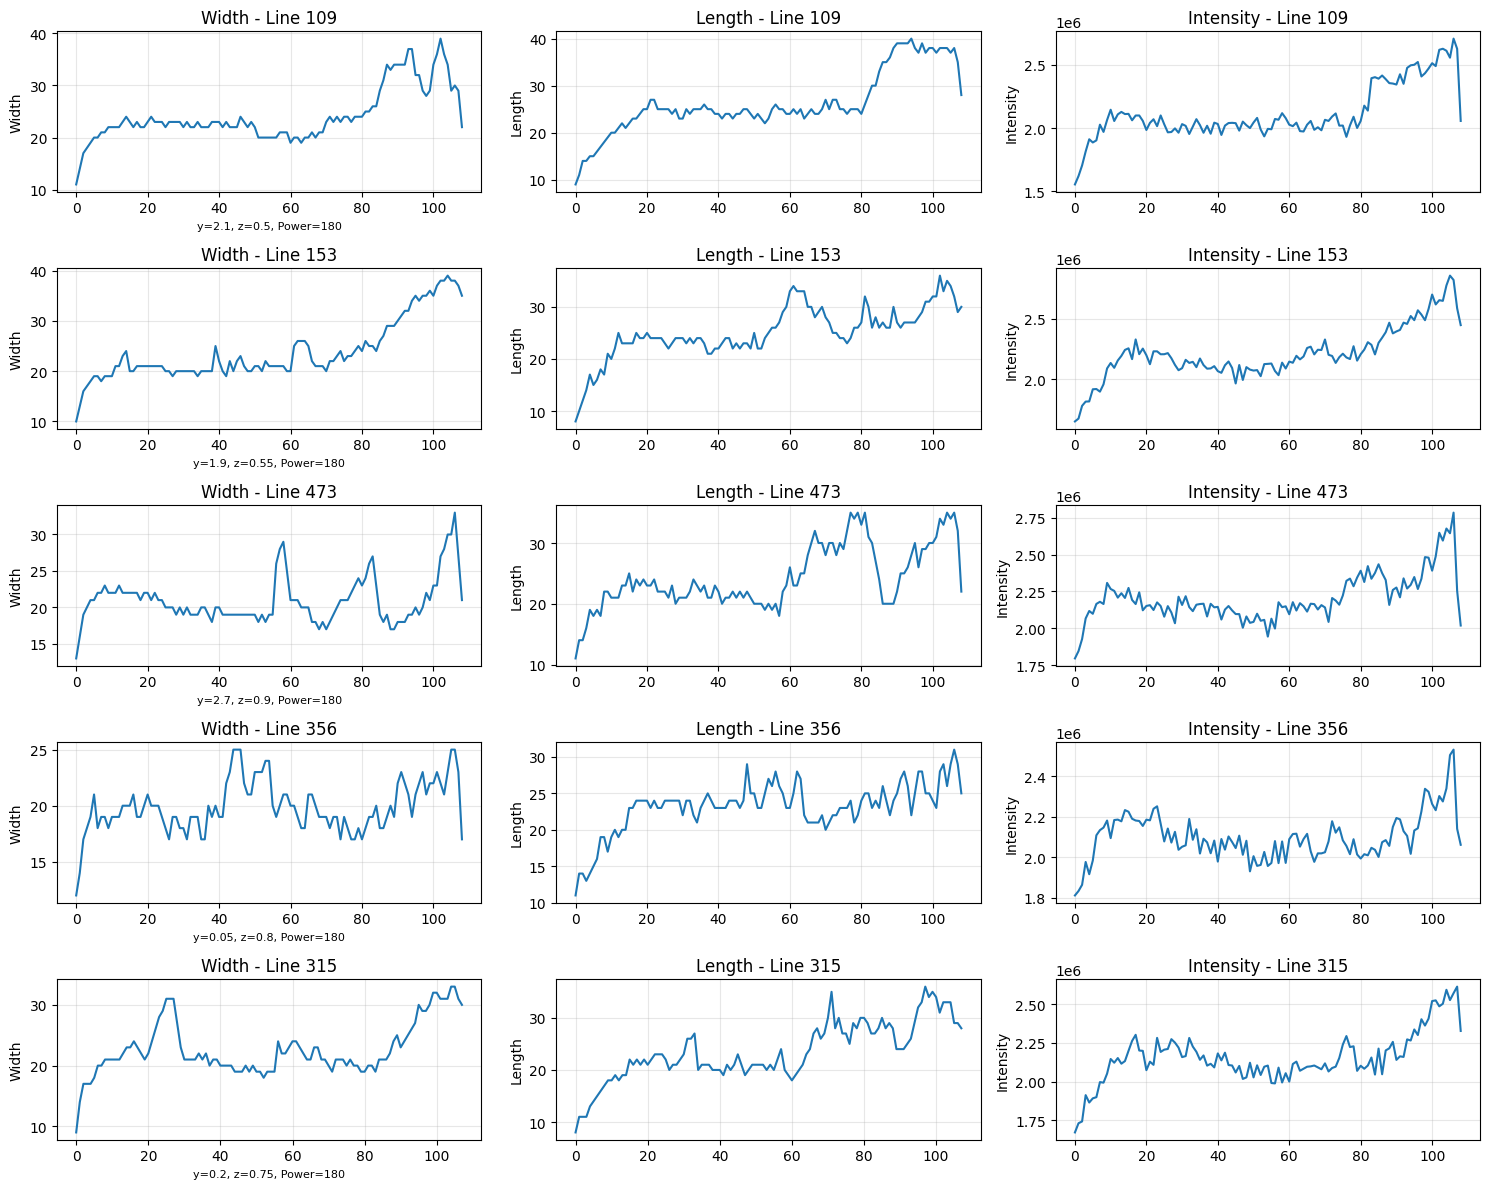

In [15]:
# Visualize random lines from each measurement type
num_lines_to_visualize = 5
random_indices = random.sample(range(len(metadata)), num_lines_to_visualize)

plt.figure(figsize=(15, 12))
for i, idx in enumerate(random_indices):
    # Width plot
    plt.subplot(num_lines_to_visualize, 3, i*3+1)
    width_values = width_data.iloc[idx]
    valid_width = width_values[width_values > 0]
    plt.plot(valid_width.values)
    plt.title(f"Width - Line {idx}")
    plt.ylabel("Width")
    plt.grid(True, alpha=0.3)

    # Length plot
    plt.subplot(num_lines_to_visualize, 3, i*3+2)
    length_values = length_data.iloc[idx]
    valid_length = length_values[length_values > 0]
    plt.plot(valid_length.values)
    plt.title(f"Length - Line {idx}")
    plt.ylabel("Length")
    plt.grid(True, alpha=0.3)

    # Intensity plot
    plt.subplot(num_lines_to_visualize, 3, i*3+3)
    intensity_values = intensity_data.iloc[idx]
    valid_intensity = intensity_values[intensity_values > 0]
    plt.plot(valid_intensity.values)
    plt.title(f"Intensity - Line {idx}")
    plt.ylabel("Intensity")
    plt.grid(True, alpha=0.3)

    # Add metadata as subtitle to first plot in row
    meta_text = f"y={metadata.iloc[idx, 0]}, z={metadata.iloc[idx, 1]}, Power={metadata.iloc[idx, 2]}"
    plt.subplot(num_lines_to_visualize, 3, i*3+1)
    plt.xlabel(meta_text, fontsize=8)

plt.tight_layout()
plt.show()

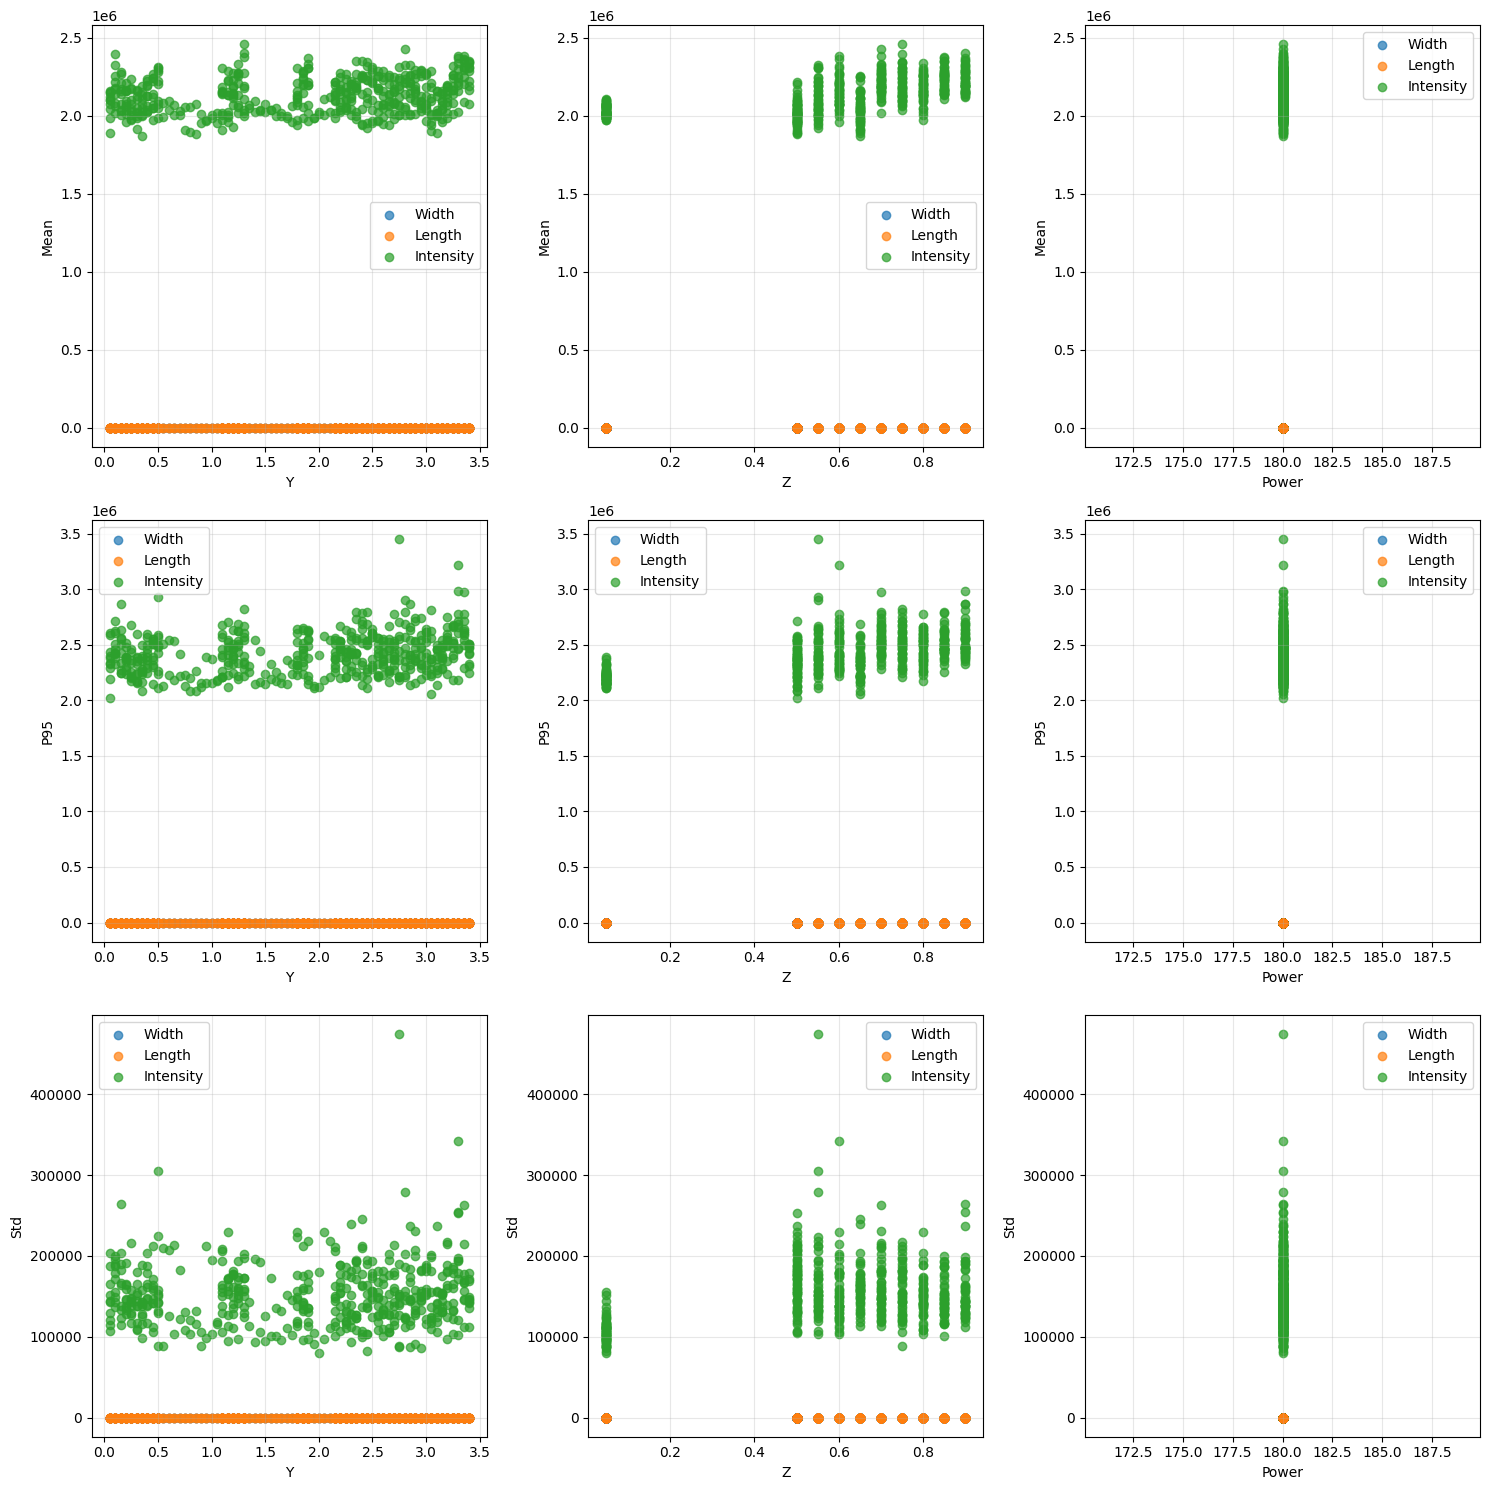

In [16]:
# Create scatter plots comparing all three measurements against coordinates
coords = ['y', 'z', 'power']
features = ['width', 'length', 'intensity']
metrics = ['mean', 'p95', 'std']

fig, axs = plt.subplots(len(metrics), len(coords), figsize=(15, 15))

for i, metric in enumerate(metrics):
    for j, coord in enumerate(coords):
        for feature in features:
            stat_column = f'{feature}_{metric}'
            axs[i, j].scatter(stats[coord], stats[stat_column], alpha=0.7, label=feature.capitalize())
        axs[i, j].set_xlabel(coord.capitalize())
        axs[i, j].set_ylabel(f"{metric.capitalize()}")
        axs[i, j].grid(True, alpha=0.3)
        axs[i, j].legend()

plt.tight_layout()
plt.show()

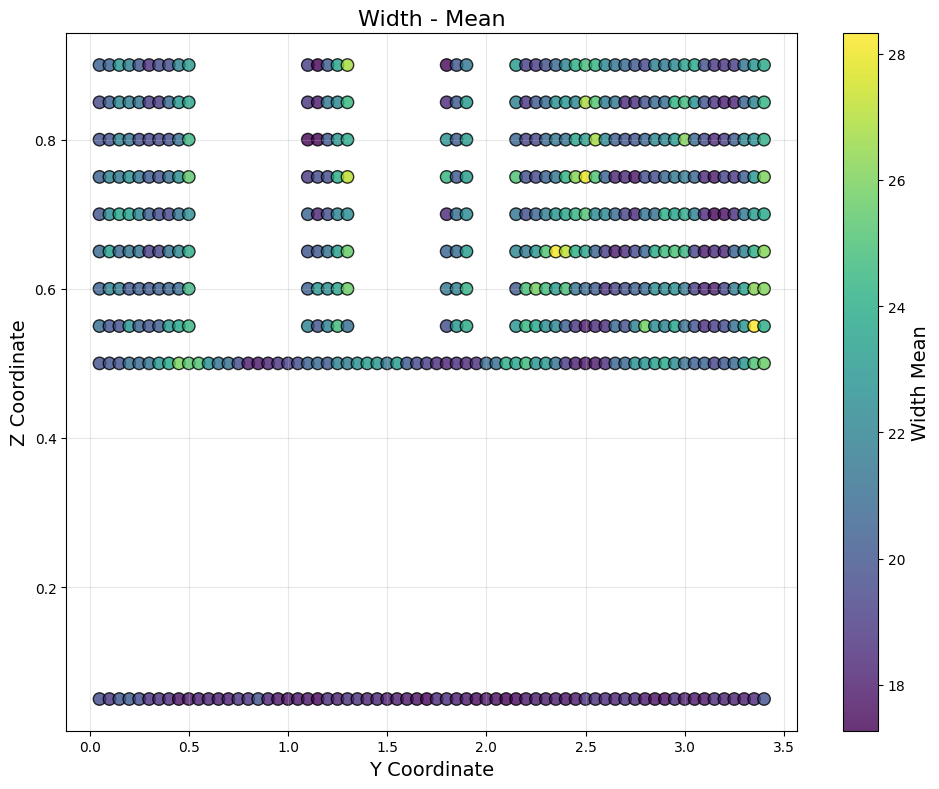

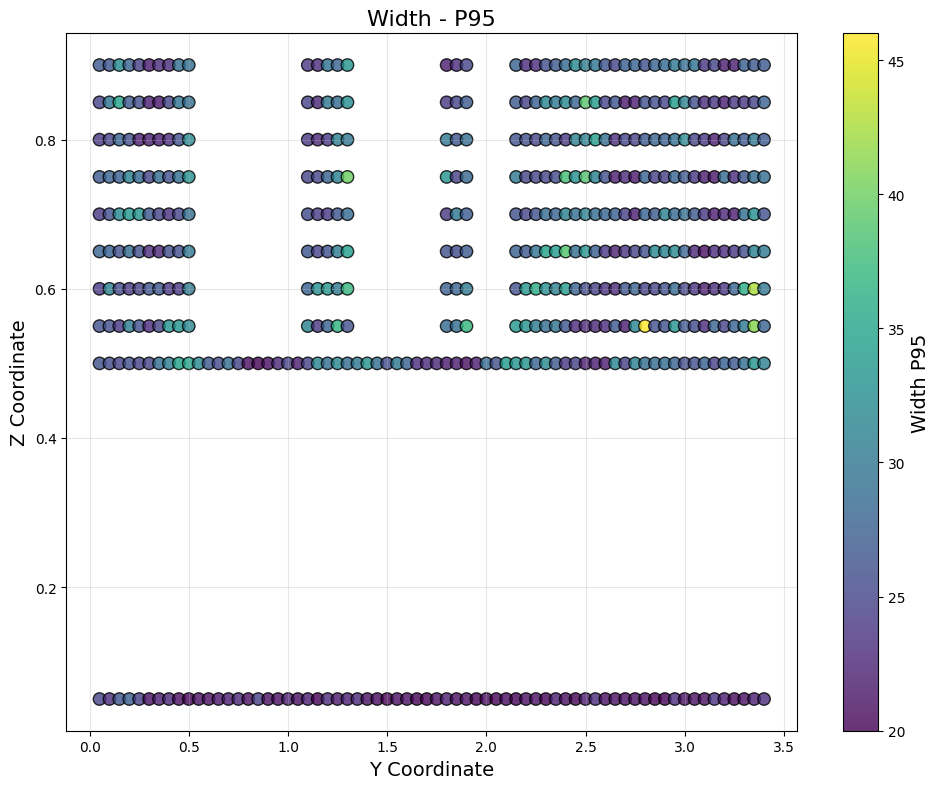

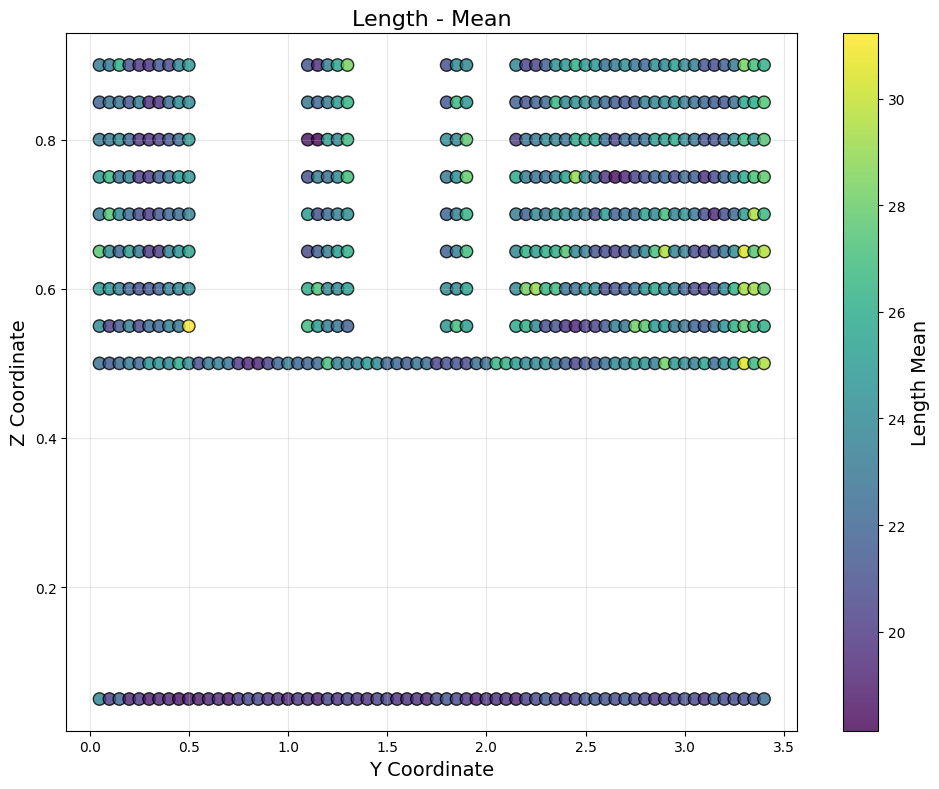

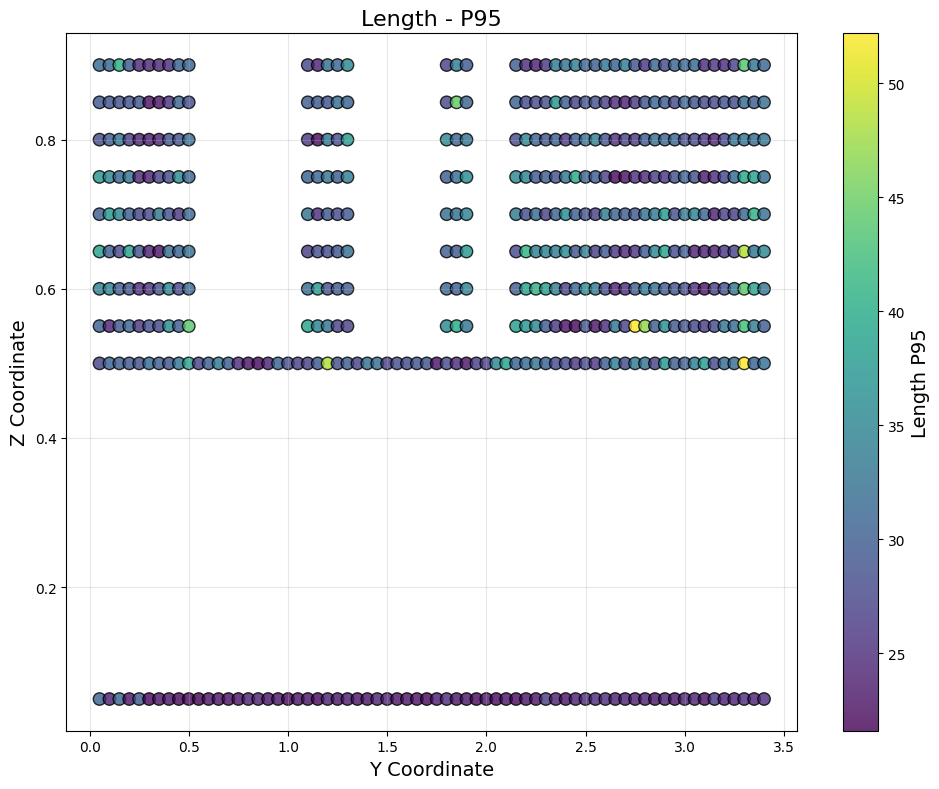

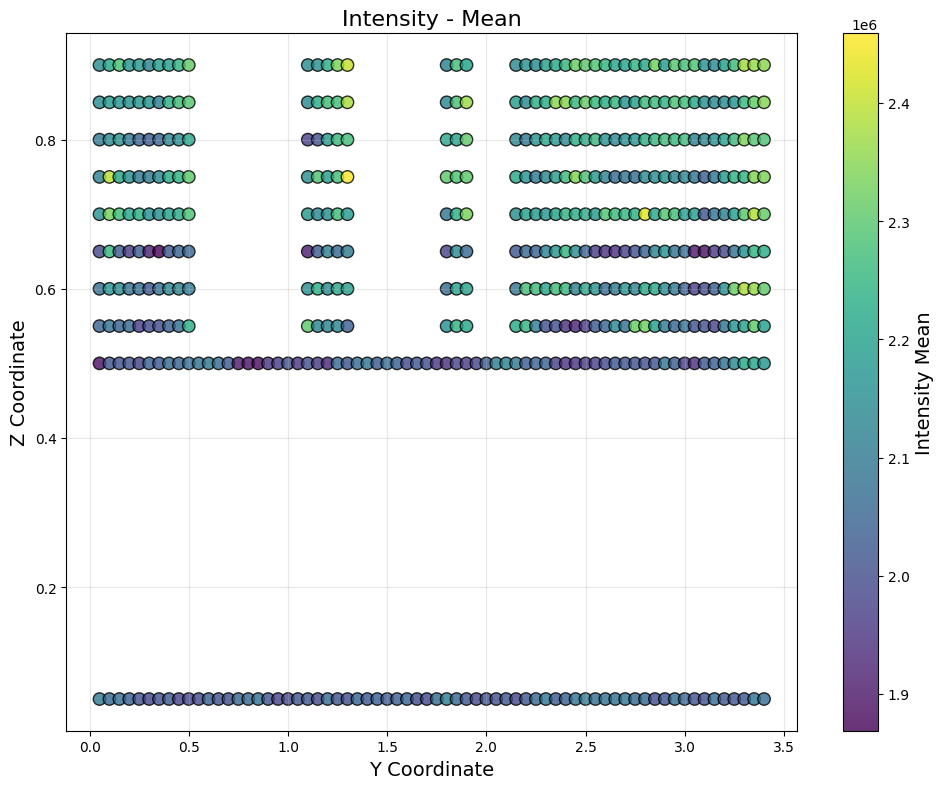

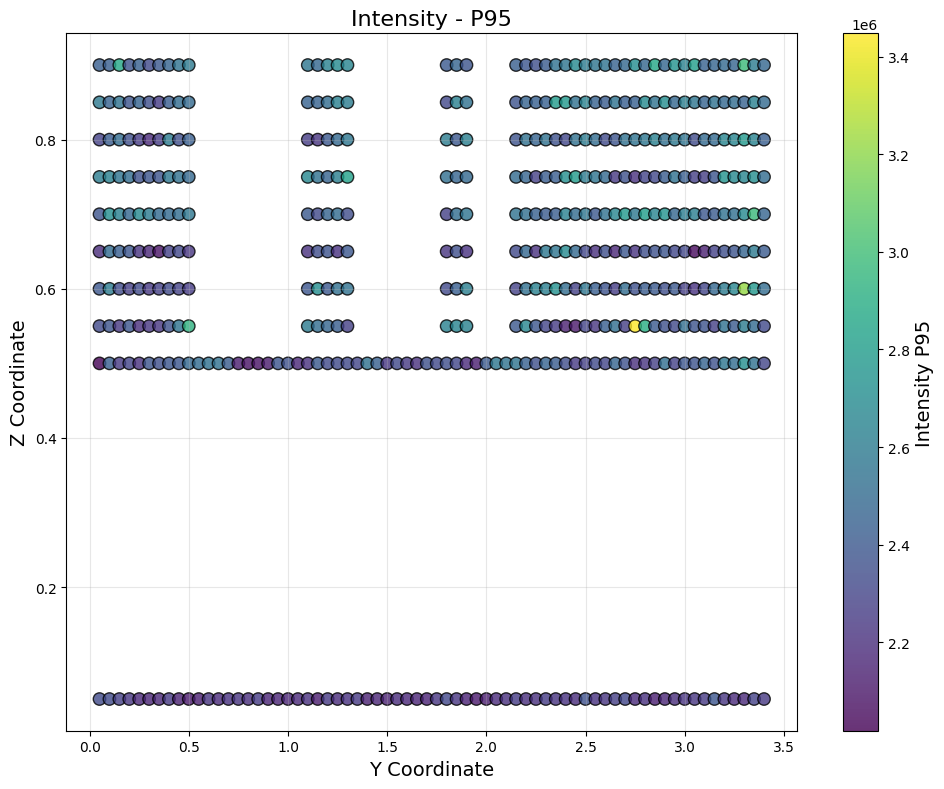

In [17]:
# Create 2D heatmaps for each measurement feature
for feature in features:
    for metric in ['mean', 'p95']:
        stat_column = f'{feature}_{metric}'

        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(stats['y'], stats['z'], c=stats[stat_column],
                            s=80, cmap='viridis', alpha=0.8, edgecolors='k')
        plt.xlabel('Y Coordinate', fontsize=14)
        plt.ylabel('Z Coordinate', fontsize=14)
        plt.title(f'{feature.capitalize()} - {metric.capitalize()}', fontsize=16)
        plt.grid(True, alpha=0.3)
        cbar = plt.colorbar(scatter)
        cbar.set_label(f"{feature.capitalize()} {metric.capitalize()}", fontsize=14)
        plt.tight_layout()
        plt.show()

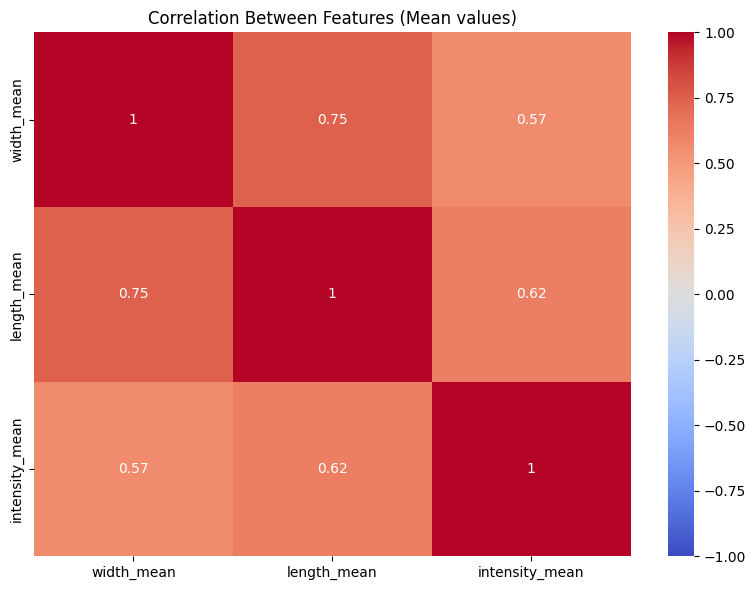

In [18]:
# Add correlation analysis between different measurements
correlation_columns = [f'{feature}_mean' for feature in features]
correlation_df = stats[correlation_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Between Features (Mean values)")
plt.tight_layout()
plt.show()

In [ ]:
# y scale: 10.4 um / px